In [ ]:
import json
import warnings
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix, classification_report)

warnings.filterwarnings("ignore")
RANDOM_STATE = 42

In [ ]:
from google.colab import files
uploaded = files.upload()

filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

print(f"[RAW] shape = {df.shape}")
df.head()

Saving Heart Attack.csv to Heart Attack.csv
[RAW] shape = (1319, 9)


,age,gender,impluse,pressurehight,pressurelow,glucose,kcm,troponin,class
0,64,1,66,160,83,160.0,1.80,0.012,negative
1,21,1,94,98,46,296.0,6.75,1.060,positive
2,55,1,64,160,77,270.0,1.99,0.003,negative
3,64,1,70,120,55,270.0,13.87,0.122,positive
4,55,1,64,112,65,300.0,1.08,0.003,negative


In [ ]:
print("Columns:", list(df.columns))
print("\nShape:", df.shape)
print("\nAll dtypes:\n", df.dtypes)
print("\nNaN count per column:\n", df.isna().sum())
print("\nAny infinite values?\n", np.isinf(df.select_dtypes(include=[np.number])).sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nRaw 'class' dtype:", df["class"].dtype)
print("Raw 'class' unique values:", df["class"].unique())

Columns: ['age', 'gender', 'impluse', 'pressurehight', 'pressurelow', 'glucose', 'kcm', 'troponin', 'class']

Shape: (1319, 9)

All dtypes:
 age                int64
gender             int64
impluse            int64
pressurehight      int64
pressurelow        int64
glucose          float64
kcm              float64
troponin         float64
class             object
dtype: object

NaN count per column:
 age              0
gender           0
impluse          0
pressurehight    0
pressurelow      0
glucose          0
kcm              0
troponin         0
class            0
dtype: int64

Any infinite values?
 age              0
gender           0
impluse          0
pressurehight    0
pressurelow      0
glucose          0
kcm              0
troponin         0
dtype: int64

Duplicate rows: 0

Raw 'class' dtype: object
Raw 'class' unique values: ['negative' 'positive']


In [ ]:
n_before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"[CLEAN] removed {n_before - len(df)} duplicate rows -> shape = {df.shape}")

print("Raw 'class' dtype:", df["class"].dtype)
print("Raw 'class' unique values:", df["class"].unique())

if df["class"].dtype == object:
    df["class"] = df["class"].astype(str).str.strip().str.lower().map({"positive": 1, "negative": 0})
else:
    df["class"] = df["class"].astype(int)

n_unmapped = df["class"].isna().sum()
if n_unmapped:
    print(f"[WARNING] {n_unmapped} rows in 'class' didn't map — inspect these:")
    print(df.loc[df["class"].isna()])
else:
    print("[CLEAN] 'class' column encoded successfully (1=positive, 0=negative)")

X = df.drop(columns=["class"])
y = df["class"]
y.value_counts()

[CLEAN] removed 0 duplicate rows -> shape = (1319, 9)
Raw 'class' dtype: object
Raw 'class' unique values: ['negative' 'positive']
[CLEAN] 'class' column encoded successfully (1=positive, 0=negative)


,count
class,
1,810
0,509


In [ ]:
rows_with_na = X.isna().any(axis=1).sum()
print(f"Rows with missing feature values: {rows_with_na} out of {len(X)}")

mask = ~X.isna().any(axis=1)
X = X[mask].reset_index(drop=True)
y = y[mask].reset_index(drop=True)
print(f"[CLEAN] Dropped {(~mask).sum()} rows with missing values -> X shape = {X.shape}")

Rows with missing feature values: 0 out of 1319
[CLEAN] Dropped 0 rows with missing values -> X shape = (1319, 8)


In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_STATE
)
print(f"[SPLIT] train={X_train.shape} ({len(X_train)/len(X):.0%}), "
      f"val={X_val.shape} ({len(X_val)/len(X):.0%}), "
      f"test={X_test.shape} ({len(X_test)/len(X):.0%})")

[SPLIT] train=(923, 8) (70%), val=(198, 8) (15%), test=(198, 8) (15%)


In [ ]:
X_train = X_train.copy()
X_val = X_val.copy()
X_test = X_test.copy()

for split_name, Xs in [("train", X_train), ("val", X_val), ("test", X_test)]:
    n_invalid = (Xs["impluse"] > 220).sum()
    if n_invalid:
        print(f"[PREP] {split_name}: {n_invalid} invalid 'impluse' values flagged")
    Xs.loc[Xs["impluse"] > 220, "impluse"] = np.nan

train_medians = X_train.median(numeric_only=True)
for Xs in (X_train, X_val, X_test):
    Xs.fillna(train_medians, inplace=True)

[PREP] train: 2 invalid 'impluse' values flagged
[PREP] test: 1 invalid 'impluse' values flagged


In [ ]:
outlier_report = {}
for col in X_train.columns:
    q1, q3 = X_train[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outlier_report[col] = (round(lower, 2), round(upper, 2))
    for Xs in (X_train, X_val, X_test):
        Xs[col] = Xs[col].clip(lower, upper)

print("[PREP] IQR bounds (from train):")
for col, bounds in outlier_report.items():
    print(f"       {col}: {bounds}")

[PREP] IQR bounds (from train):
       age: (22.5, 90.5)
       gender: (-1.5, 2.5)
       impluse: (30.0, 118.0)
       pressurehight: (60.5, 192.5)
       pressurelow: (32.5, 108.5)
       glucose: (-11.0, 277.0)
       kcm: (-4.06, 11.18)
       troponin: (-0.13, 0.23)


In [ ]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns, index=X_train.index)
X_val_scaled = pd.DataFrame(scaler.transform(X_val), columns=X.columns, index=X_val.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X.columns, index=X_test.index)

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

model_grids = {
    "Logistic Regression": (
        LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
        {"C": [0.01, 0.1, 1, 10, 100], "solver": ["lbfgs"]},
        True,
    ),
    "Random Forest": (
        RandomForestClassifier(random_state=RANDOM_STATE),
        {"n_estimators": [200, 400], "max_depth": [None, 8, 12], "min_samples_leaf": [1, 2]},
        False,
    ),
    "XGBoost (HistGB substitute)": (
        HistGradientBoostingClassifier(random_state=RANDOM_STATE),
        {"max_iter": [150, 300], "max_depth": [None, 6, 10], "learning_rate": [0.03, 0.1]},
        False,
    ),
    "CatBoost (GradBoost substitute)": (
        GradientBoostingClassifier(random_state=RANDOM_STATE),
        {"n_estimators": [150, 300], "max_depth": [2, 3, 4], "learning_rate": [0.03, 0.1]},
        False,
    ),
}

results = {}
fitted_models = {}

for name, (estimator, grid, use_scaled) in model_grids.items():
    Xtr = X_train_scaled if use_scaled else X_train
    Xv = X_val_scaled if use_scaled else X_val

    gs = GridSearchCV(estimator, grid, cv=cv, scoring="accuracy", n_jobs=-1)
    gs.fit(Xtr, y_train)
    best_model = gs.best_estimator_
    fitted_models[name] = (best_model, use_scaled)

    val_pred = best_model.predict(Xv)
    val_acc = accuracy_score(y_val, val_pred)

    results[name] = {
        "best_params": gs.best_params_,
        "cv_train_score": gs.best_score_,
        "val_accuracy": val_acc,
    }
    print(f"[{name}] best_params={gs.best_params_}")
    print(f"[{name}] 5-fold CV accuracy={gs.best_score_:.4f} | Validation accuracy={val_acc:.4f}\n")

[Logistic Regression] best_params={'C': 100, 'solver': 'lbfgs'}
[Logistic Regression] 5-fold CV accuracy=0.9426 | Validation accuracy=0.9545

[Random Forest] best_params={'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 200}
[Random Forest] 5-fold CV accuracy=0.9892 | Validation accuracy=0.9747

[XGBoost (HistGB substitute)] best_params={'learning_rate': 0.03, 'max_depth': 6, 'max_iter': 300}
[XGBoost (HistGB substitute)] 5-fold CV accuracy=0.9913 | Validation accuracy=0.9798

[CatBoost (GradBoost substitute)] best_params={'learning_rate': 0.03, 'max_depth': 2, 'n_estimators': 150}
[CatBoost (GradBoost substitute)] 5-fold CV accuracy=0.9892 | Validation accuracy=0.9747



In [ ]:
best_name = max(results, key=lambda k: results[k]["val_accuracy"])
best_model, use_scaled = fitted_models[best_name]
Xte = X_test_scaled if use_scaled else X_test

test_pred = best_model.predict(Xte)
test_proba = best_model.predict_proba(Xte)[:, 1] if hasattr(best_model, "predict_proba") else None

test_acc = accuracy_score(y_test, test_pred)
test_prec = precision_score(y_test, test_pred)
test_rec = recall_score(y_test, test_pred)
test_f1 = f1_score(y_test, test_pred)
test_auc = roc_auc_score(y_test, test_proba) if test_proba is not None else None

print(f"BEST MODEL (by validation accuracy): {best_name}\n")
print(f"TEST accuracy : {test_acc:.4f}")
print(f"TEST precision: {test_prec:.4f}")
print(f"TEST recall   : {test_rec:.4f}")
print(f"TEST F1       : {test_f1:.4f}")
if test_auc is not None:
    print(f"TEST ROC-AUC  : {test_auc:.4f}")
print("\nConfusion matrix (rows=true, cols=pred):")
print(confusion_matrix(y_test, test_pred))
print("\nClassification report:")
print(classification_report(y_test, test_pred, target_names=["negative", "positive"]))

BEST MODEL (by validation accuracy): XGBoost (HistGB substitute)

TEST accuracy : 0.9848
TEST precision: 0.9836
TEST recall   : 0.9917
TEST F1       : 0.9877
TEST ROC-AUC  : 0.9823

Confusion matrix (rows=true, cols=pred):
[[ 75   2]
 [  1 120]]

Classification report:
              precision    recall  f1-score   support

    negative       0.99      0.97      0.98        77
    positive       0.98      0.99      0.99       121

    accuracy                           0.98       198
   macro avg       0.99      0.98      0.98       198
weighted avg       0.98      0.98      0.98       198



In [ ]:
summary_rows = []
for name, (model, use_scaled) in fitted_models.items():
    Xte_i = X_test_scaled if use_scaled else X_test
    pred_i = model.predict(Xte_i)
    proba_i = model.predict_proba(Xte_i)[:, 1] if hasattr(model, "predict_proba") else None
    summary_rows.append({
        "Model": name,
        "CV Accuracy (train)": round(results[name]["cv_train_score"], 4),
        "Val Accuracy": round(results[name]["val_accuracy"], 4),
        "Test Accuracy": round(accuracy_score(y_test, pred_i), 4),
        "Test Precision": round(precision_score(y_test, pred_i), 4),
        "Test Recall": round(recall_score(y_test, pred_i), 4),
        "Test F1": round(f1_score(y_test, pred_i), 4),
        "Test ROC-AUC": round(roc_auc_score(y_test, proba_i), 4) if proba_i is not None else None,
    })

summary_df = pd.DataFrame(summary_rows).sort_values("Test Accuracy", ascending=False)
summary_df

,Model,CV Accuracy (train),Val Accuracy,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC-AUC
1,Random Forest,0.9892,0.9747,0.9848,0.9836,0.9917,0.9877,0.9943
2,XGBoost (HistGB substitute),0.9913,0.9798,0.9848,0.9836,0.9917,0.9877,0.9823
3,CatBoost (GradBoost substitute),0.9892,0.9747,0.9848,0.9836,0.9917,0.9877,0.9897
0,Logistic Regression,0.9426,0.9545,0.9394,0.9658,0.9339,0.9496,0.9779


In [ ]:
summary_df.to_csv("model_summary_701515.csv", index=False)
with open("results_701515.json", "w") as f:
    json.dump({"best_model": best_name, "test_accuracy": test_acc,
               "outlier_bounds_from_train": outlier_report,
               "results_per_model": results}, f, indent=2)
print("Saved: model_summary_701515.csv, results_701515.json")

Saved: model_summary_701515.csv, results_701515.json


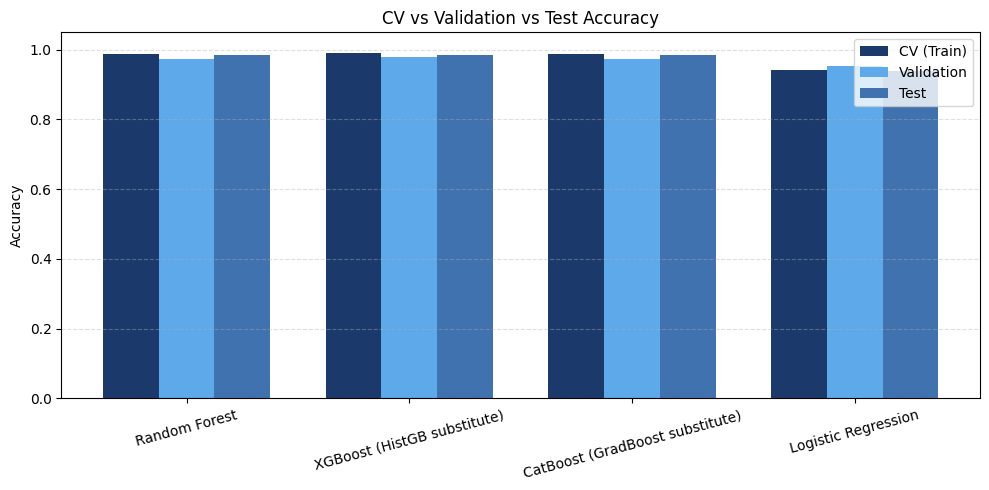

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(len(summary_df))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width, summary_df["CV Accuracy (train)"], width, label="CV (Train)", color="#1B3A6B")
ax.bar(x,          summary_df["Val Accuracy"],        width, label="Validation", color="#5DA9E9")
ax.bar(x + width,  summary_df["Test Accuracy"],       width, label="Test",       color="#3F72AF")

ax.set_title("CV vs Validation vs Test Accuracy")
ax.set_ylabel("Accuracy")
ax.set_xticks(x)
ax.set_xticklabels(summary_df["Model"], rotation=15)
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

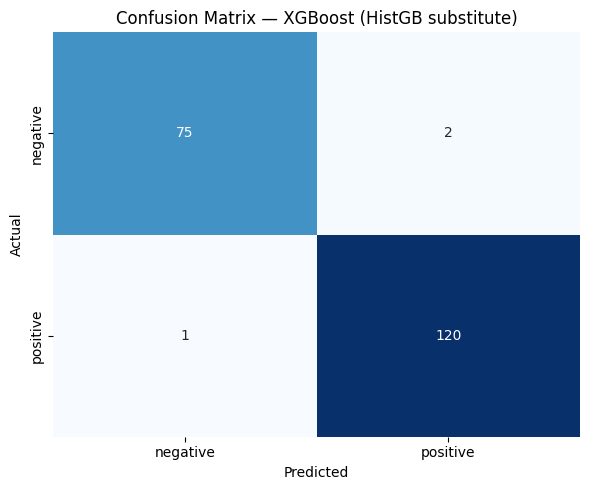

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, test_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["negative", "positive"],
    yticklabels=["negative", "positive"],
    cbar=False
)
plt.title(f"Confusion Matrix — {best_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

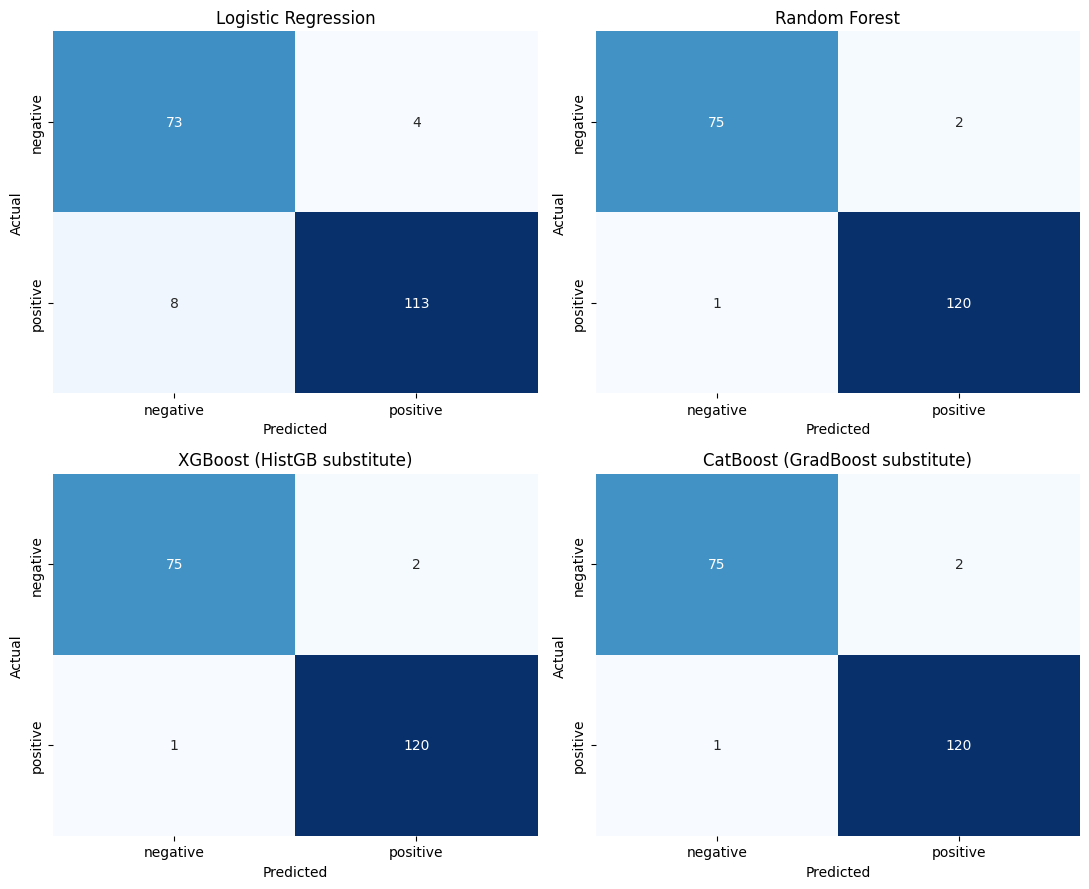

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
axes = axes.flatten()

for ax, (name, (model, use_scaled)) in zip(axes, fitted_models.items()):
    Xte_i = X_test_scaled if use_scaled else X_test
    pred_i = model.predict(Xte_i)
    cm = confusion_matrix(y_test, pred_i)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["negative", "positive"],
        yticklabels=["negative", "positive"],
        cbar=False,
        ax=ax
    )
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

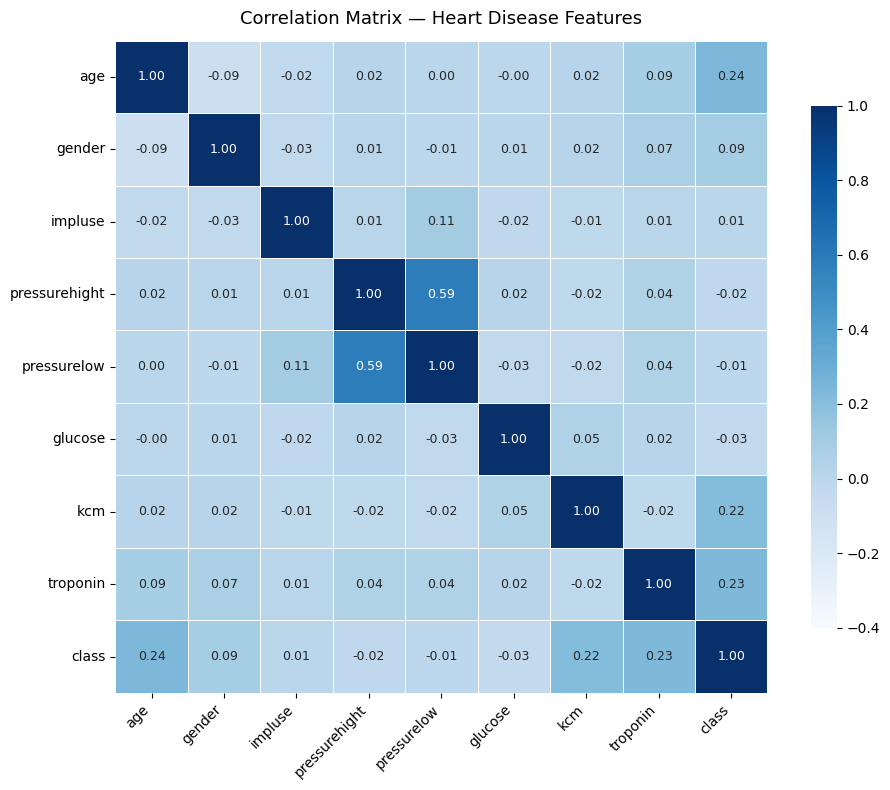


Correlation with 'class':
age              0.238
troponin         0.229
kcm              0.218
gender           0.094
glucose         -0.033
pressurehight   -0.021
pressurelow     -0.010
impluse          0.007
Name: class, dtype: float64


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# df already has 'class' encoded as 1 = positive, 0 = negative
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    vmin=-0.4, vmax=1,
    square=True,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"shrink": 0.8},
    annot_kws={"size": 9}
)
plt.title("Correlation Matrix — Heart Disease Features", fontsize=13, pad=12)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# quick ranking of what correlates most with the target
print("\nCorrelation with 'class':")
print(corr["class"].drop("class").sort_values(key=np.abs, ascending=False).round(3))

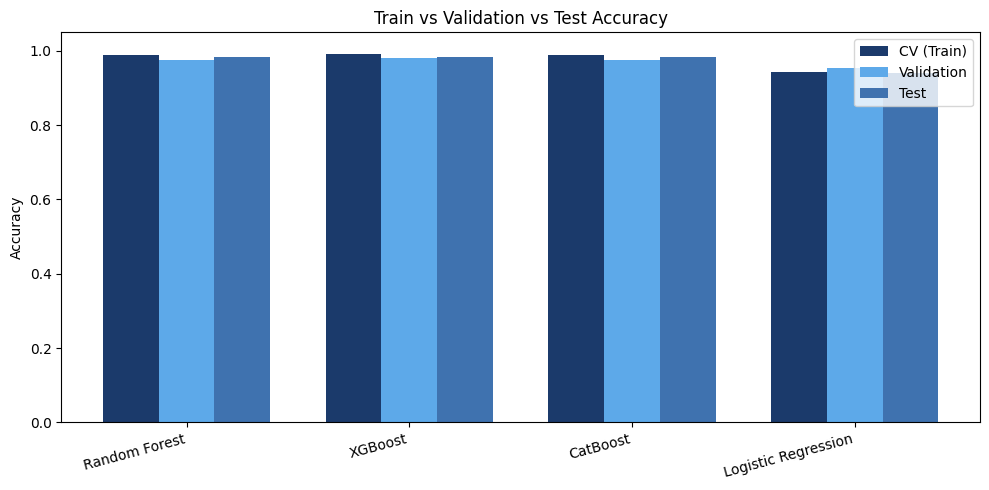

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# short display names for the x-axis, mapped from the full model names
name_map = {
    "Random Forest": "Random Forest",
    "XGBoost (HistGB substitute)": "XGBoost",
    "CatBoost (GradBoost substitute)": "CatBoost",
    "Logistic Regression": "Logistic Regression",
}
short_labels = summary_df["Model"].map(name_map)

x = np.arange(len(summary_df))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width, summary_df["CV Accuracy (train)"], width, label="CV (Train)", color="#1B3A6B")
ax.bar(x,          summary_df["Val Accuracy"],        width, label="Validation", color="#5DA9E9")
ax.bar(x + width,  summary_df["Test Accuracy"],       width, label="Test",       color="#3F72AF")

ax.set_title("Train vs Validation vs Test Accuracy")
ax.set_ylabel("Accuracy")
ax.set_xticks(x)
ax.set_xticklabels(short_labels, rotation=15, ha="right")
ax.set_ylim(0, 1.05)
ax.legend()

plt.tight_layout()
plt.show()

[Random Forest] TN=75  FP=2  FN=1  TP=120
Classification report — Random Forest:
              precision    recall  f1-score   support

    negative       0.99      0.97      0.98        77
    positive       0.98      0.99      0.99       121

    accuracy                           0.98       198
   macro avg       0.99      0.98      0.98       198
weighted avg       0.98      0.98      0.98       198

------------------------------------------------------------
[XGBoost] TN=75  FP=2  FN=1  TP=120
Classification report — XGBoost:
              precision    recall  f1-score   support

    negative       0.99      0.97      0.98        77
    positive       0.98      0.99      0.99       121

    accuracy                           0.98       198
   macro avg       0.99      0.98      0.98       198
weighted avg       0.98      0.98      0.98       198

------------------------------------------------------------


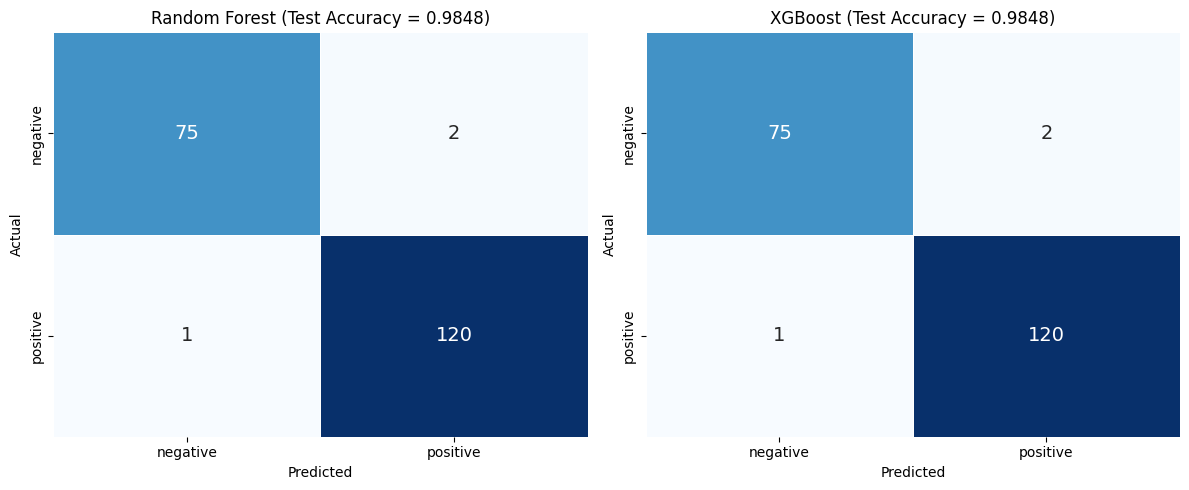

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, model_key, title in zip(
    axes,
    ["Random Forest", "XGBoost (HistGB substitute)"],
    ["Random Forest", "XGBoost"]
):
    model, use_scaled = fitted_models[model_key]
    Xte = X_test_scaled if use_scaled else X_test
    pred = model.predict(Xte)
    cm = confusion_matrix(y_test, pred)
    acc = accuracy_score(y_test, pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["negative", "positive"],
        yticklabels=["negative", "positive"],
        cbar=False,
        linewidths=0.5,
        annot_kws={"size": 14},
        ax=ax
    )
    ax.set_title(f"{title} (Test Accuracy = {acc:.4f})")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

    tn, fp, fn, tp = cm.ravel()
    print(f"[{title}] TN={tn}  FP={fp}  FN={fn}  TP={tp}")
    print(f"Classification report — {title}:")
    print(classification_report(y_test, pred, target_names=["negative", "positive"]))
    print("-" * 60)

plt.tight_layout()
plt.show()